In [1]:
!pip install kagglehub --upgrade

In [2]:
import kagglehub

/home/ujjwal/ujjwal/Hybrid-Recommender-system/recom-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#download the dataset form kaggle 
kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

'/home/ujjwal/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1'

In [4]:
import os 
from pathlib import Path 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [5]:
data_path = Path('/home/ujjwal/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1')

songs_data_path = data_path/ 'Music Info.csv'
users_data_path= data_path/ 'User Listening History.csv'

In [6]:
# songs_data

songs_df = pd.read_csv(songs_data_path, usecols=["track_id","name","artist","spotify_preview_url"])

songs_df.shape

(50683, 4)

import 

In [7]:
import dask.dataframe as dd

# Load the dataset
df = dd.read_csv(users_data_path)

# Check the first few rows to verify the data
df.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [8]:
df.npartitions #number of partition 

9

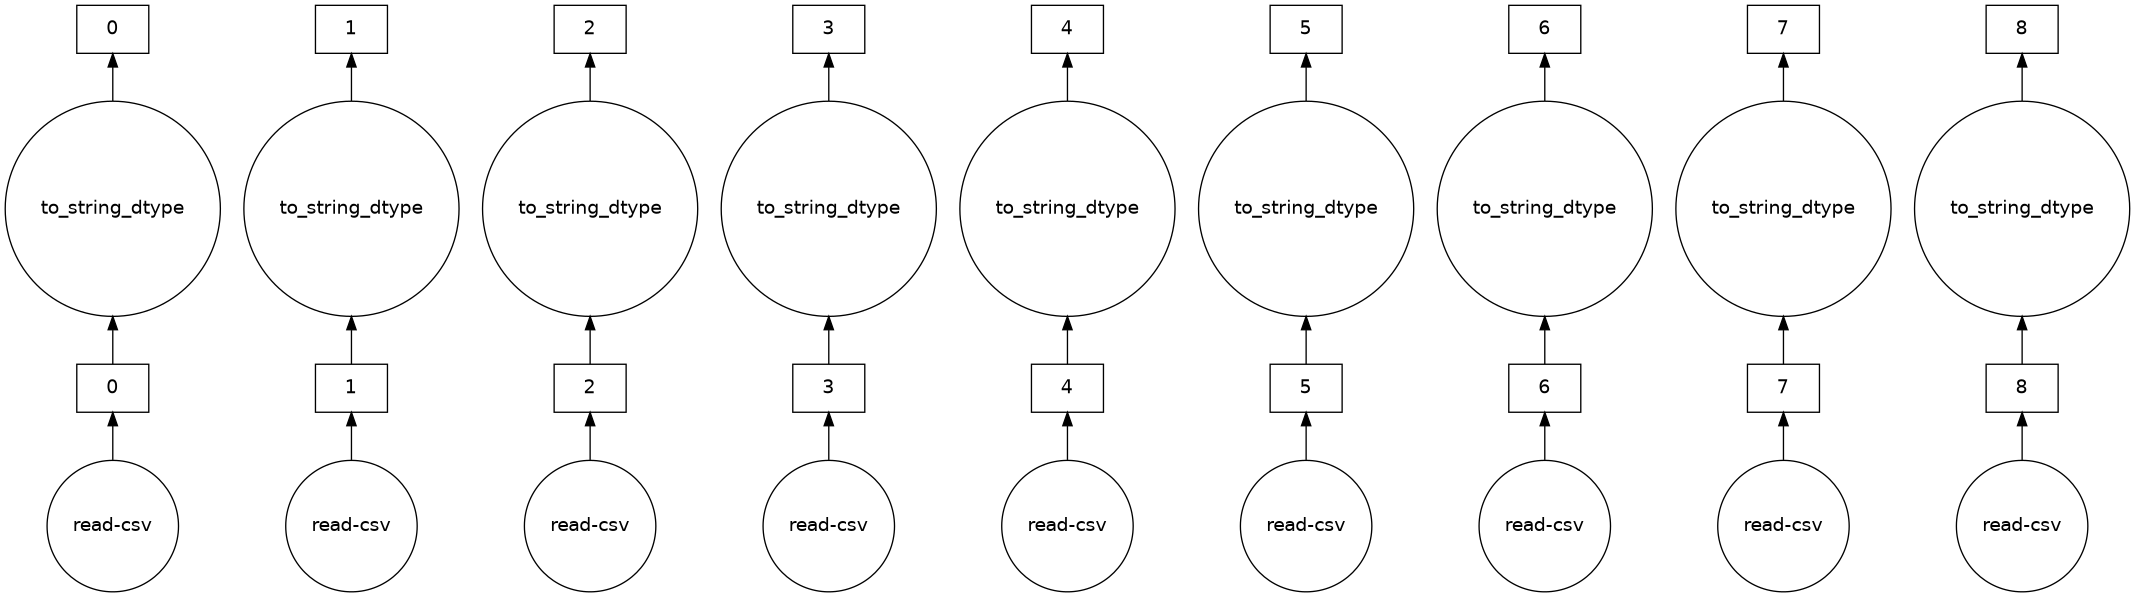

In [9]:
df.visualize(tasks=True)

In [10]:
df.columns

Index(['track_id', 'user_id', 'playcount'], dtype='object')

In [11]:
# number of unique tracks in the data

unique_tracks = df.loc[:,"track_id"].nunique()

unique_tracks_numbers = unique_tracks.compute()

unique_tracks_numbers

np.int64(30459)

In [12]:
## unique tracks id 
unique_tracks_ids= df.loc[: , "track_id"].unique().compute()
unique_tracks_ids= unique_tracks_ids.tolist()
unique_tracks_ids[:5]

['TRLXSNR128F429361D',
 'TRPUGUW128F426BF6F',
 'TRISTWT128F1488FBB',
 'TRKPWGR128E078EE06',
 'TRXQJWK128F146DF76']

In [13]:
# number of unique users in the data

unique_users = df.loc[:,"user_id"].nunique()

unique_users = unique_users.compute()

unique_users

np.int64(962037)

In [14]:
unique_tracks

<dask_expr.expr.Scalar: expr=(DropDuplicates(frame=ArrowStringConversion(frame=FromMapProjectable(6b78f54))['track_id'], split_every=False)).count(), dtype=int64>

In [15]:
#filtered songs 
filtered_songs= songs_df[songs_df['track_id'].isin(unique_tracks_ids)]

filtered_songs.reset_index(drop = True , inplace = True)
filtered_songs

,track_id,name,artist,spotify_preview_url
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...
2,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...
3,TRXOGZT128F424AD74,Karma Police,Radiohead,https://p.scdn.co/mp3-preview/5a09f5390e2862af...
4,TRUJIIV12903CA8848,Clocks,Coldplay,https://p.scdn.co/mp3-preview/24c7fe858b234e3c...
...,...,...,...,...
30454,TRXWSIN128F9339A11,Infinite Love Song,Maximilian Hecker,https://p.scdn.co/mp3-preview/8b3d529025fe3c60...
30455,TRPIGDW12903CDEB2D,Slip of the Lip,Fact,https://p.scdn.co/mp3-preview/cf64490291f9a600...
30456,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/d2668a5a3e0b1fda...
30457,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...


In [16]:
filtered_songs[filtered_songs["name"] == "Colors Of The Wind"] 

,track_id,name,artist,spotify_preview_url
30457,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...


In [17]:
from scipy.sparse import csr_matrix 

df = dd.read_csv(users_data_path) # load data with dask

df['playcount'] = df['playcount'].astype(np.float64) ## ensure playcount is numeric
df = df.categorize(columns=['user_id' , 'track_id']) ## categorize  and then in future making  gropyby using userid and track id both 

#convert user id and track id to numeric indicies for sparce matrix 
user_mapping = df['user_id'].cat.codes 
track_mapping= df['track_id'].cat.codes # just like .str , .cat is for converting to category 

df = df.assign(
    user_idx=  user_mapping,
    track_idx= track_mapping
)

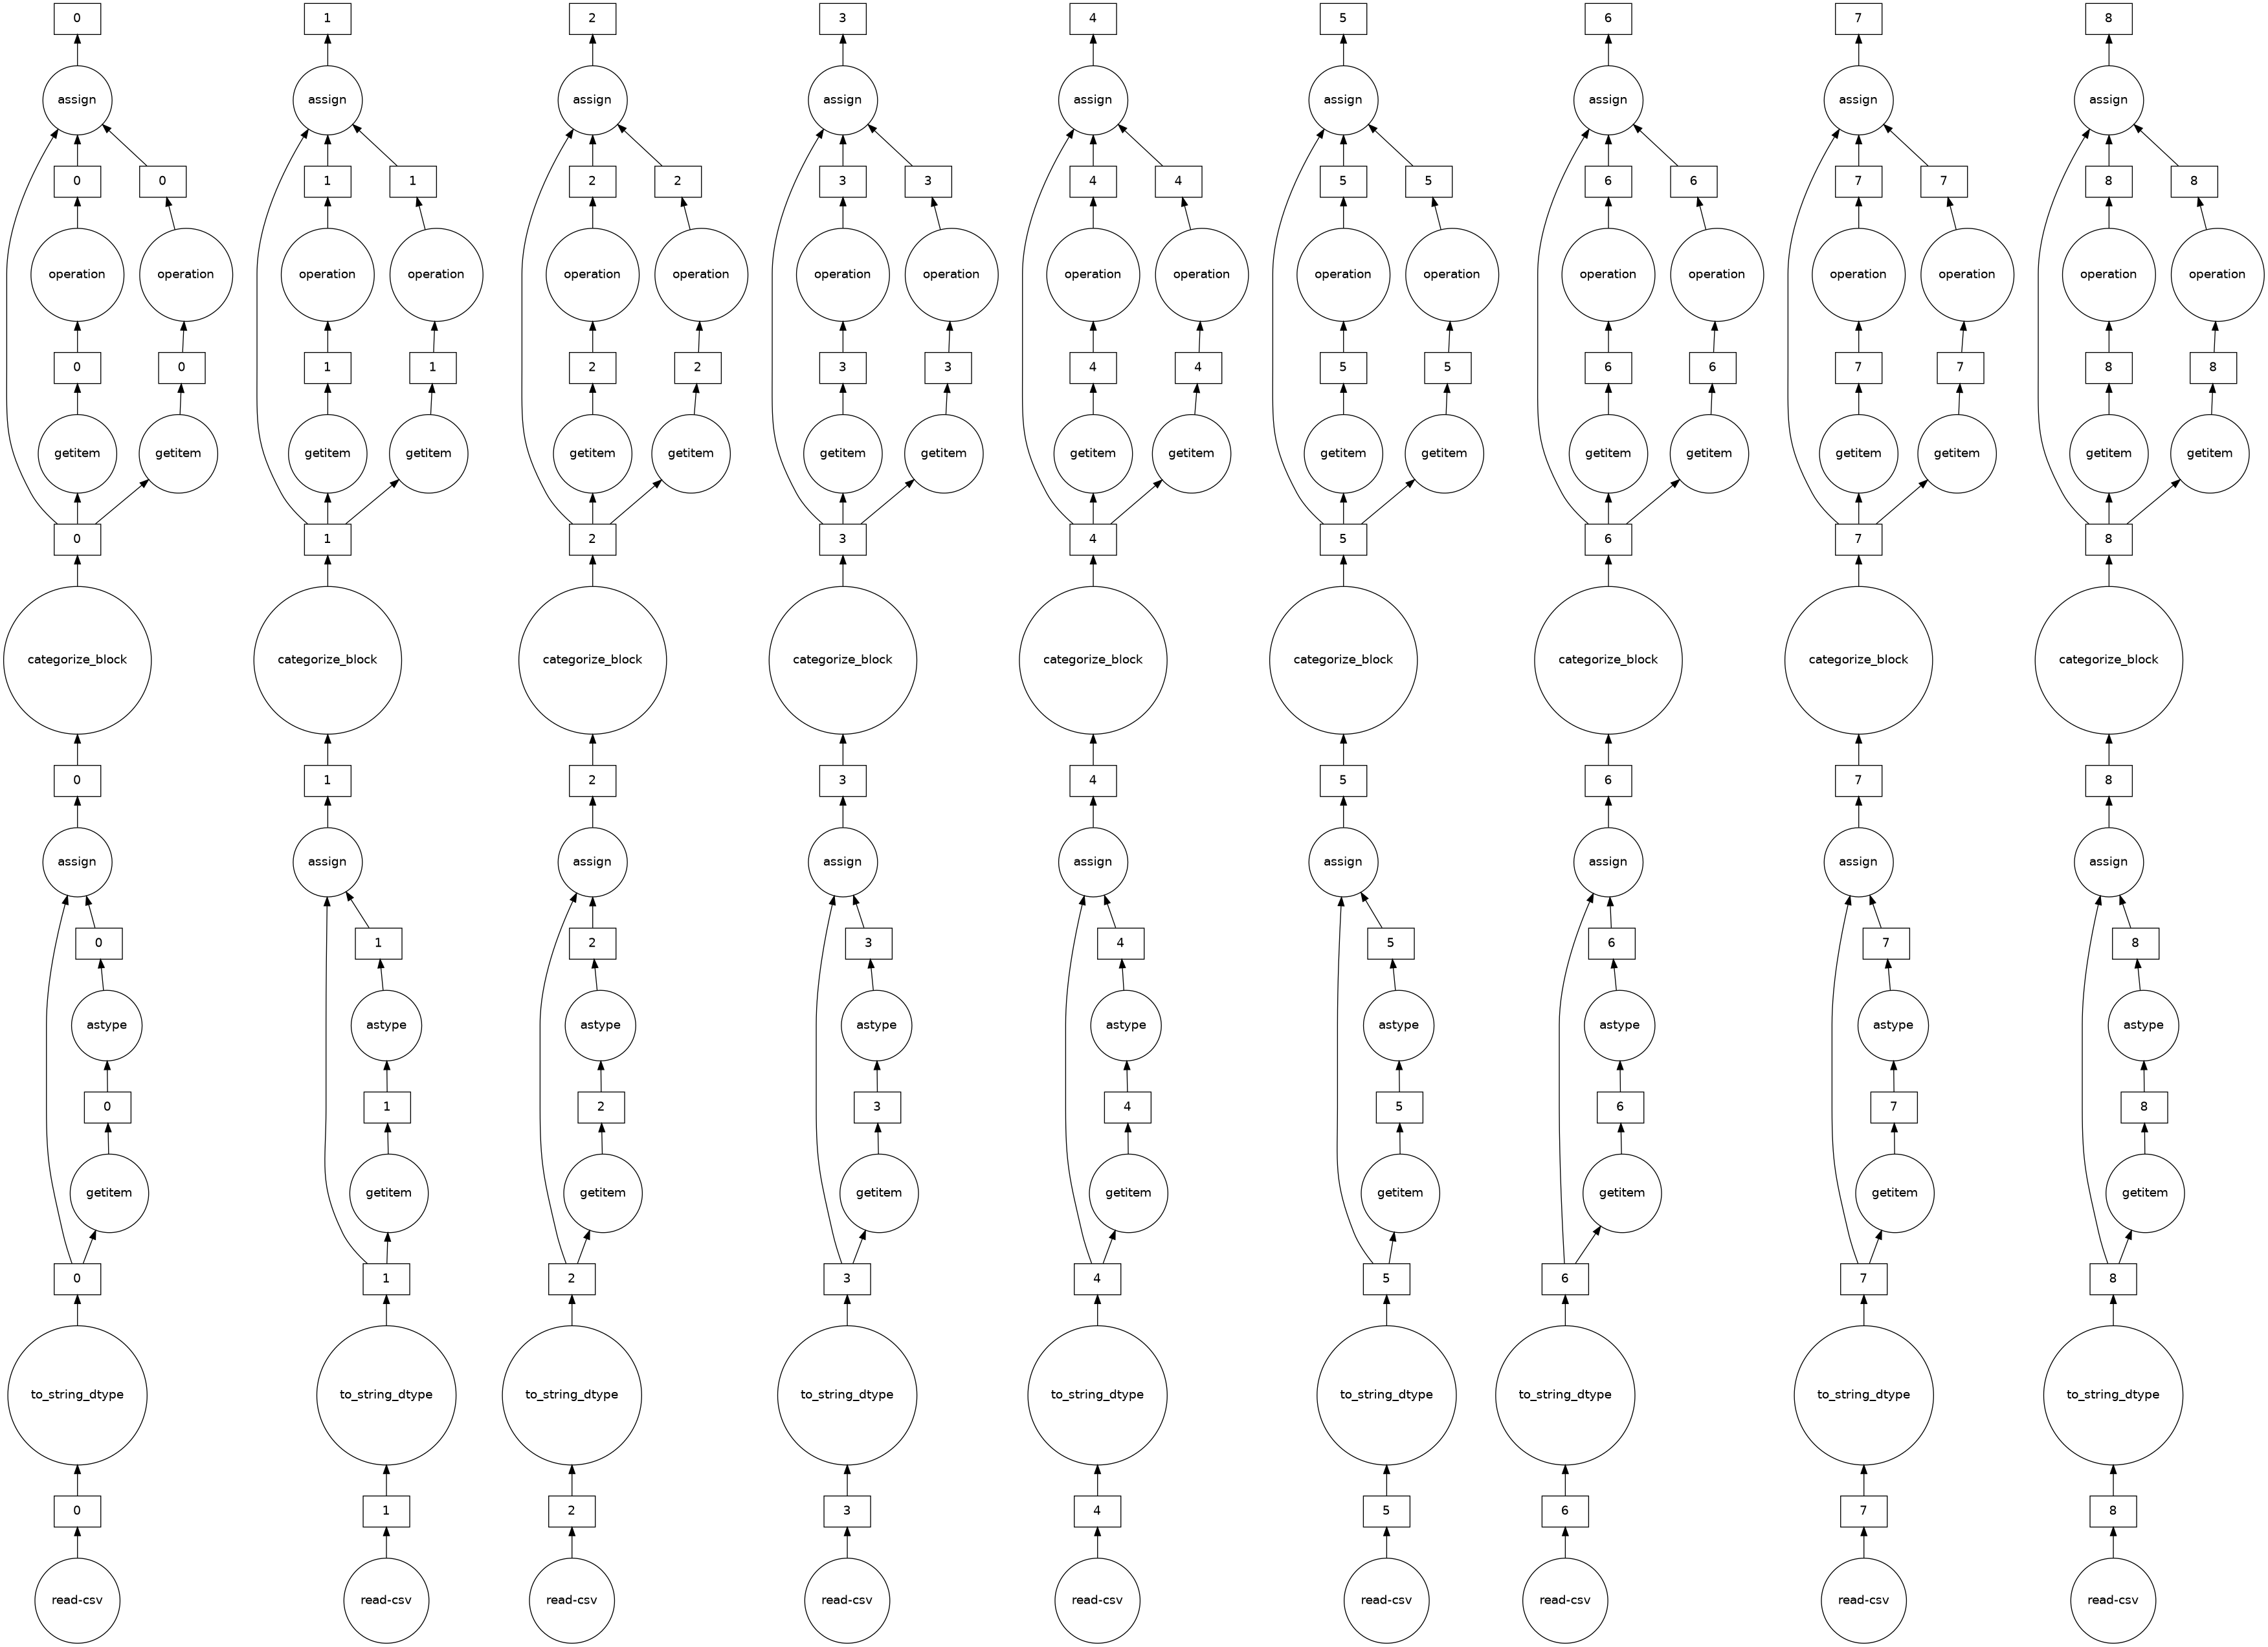

In [18]:
df.visualize(tasks= True)

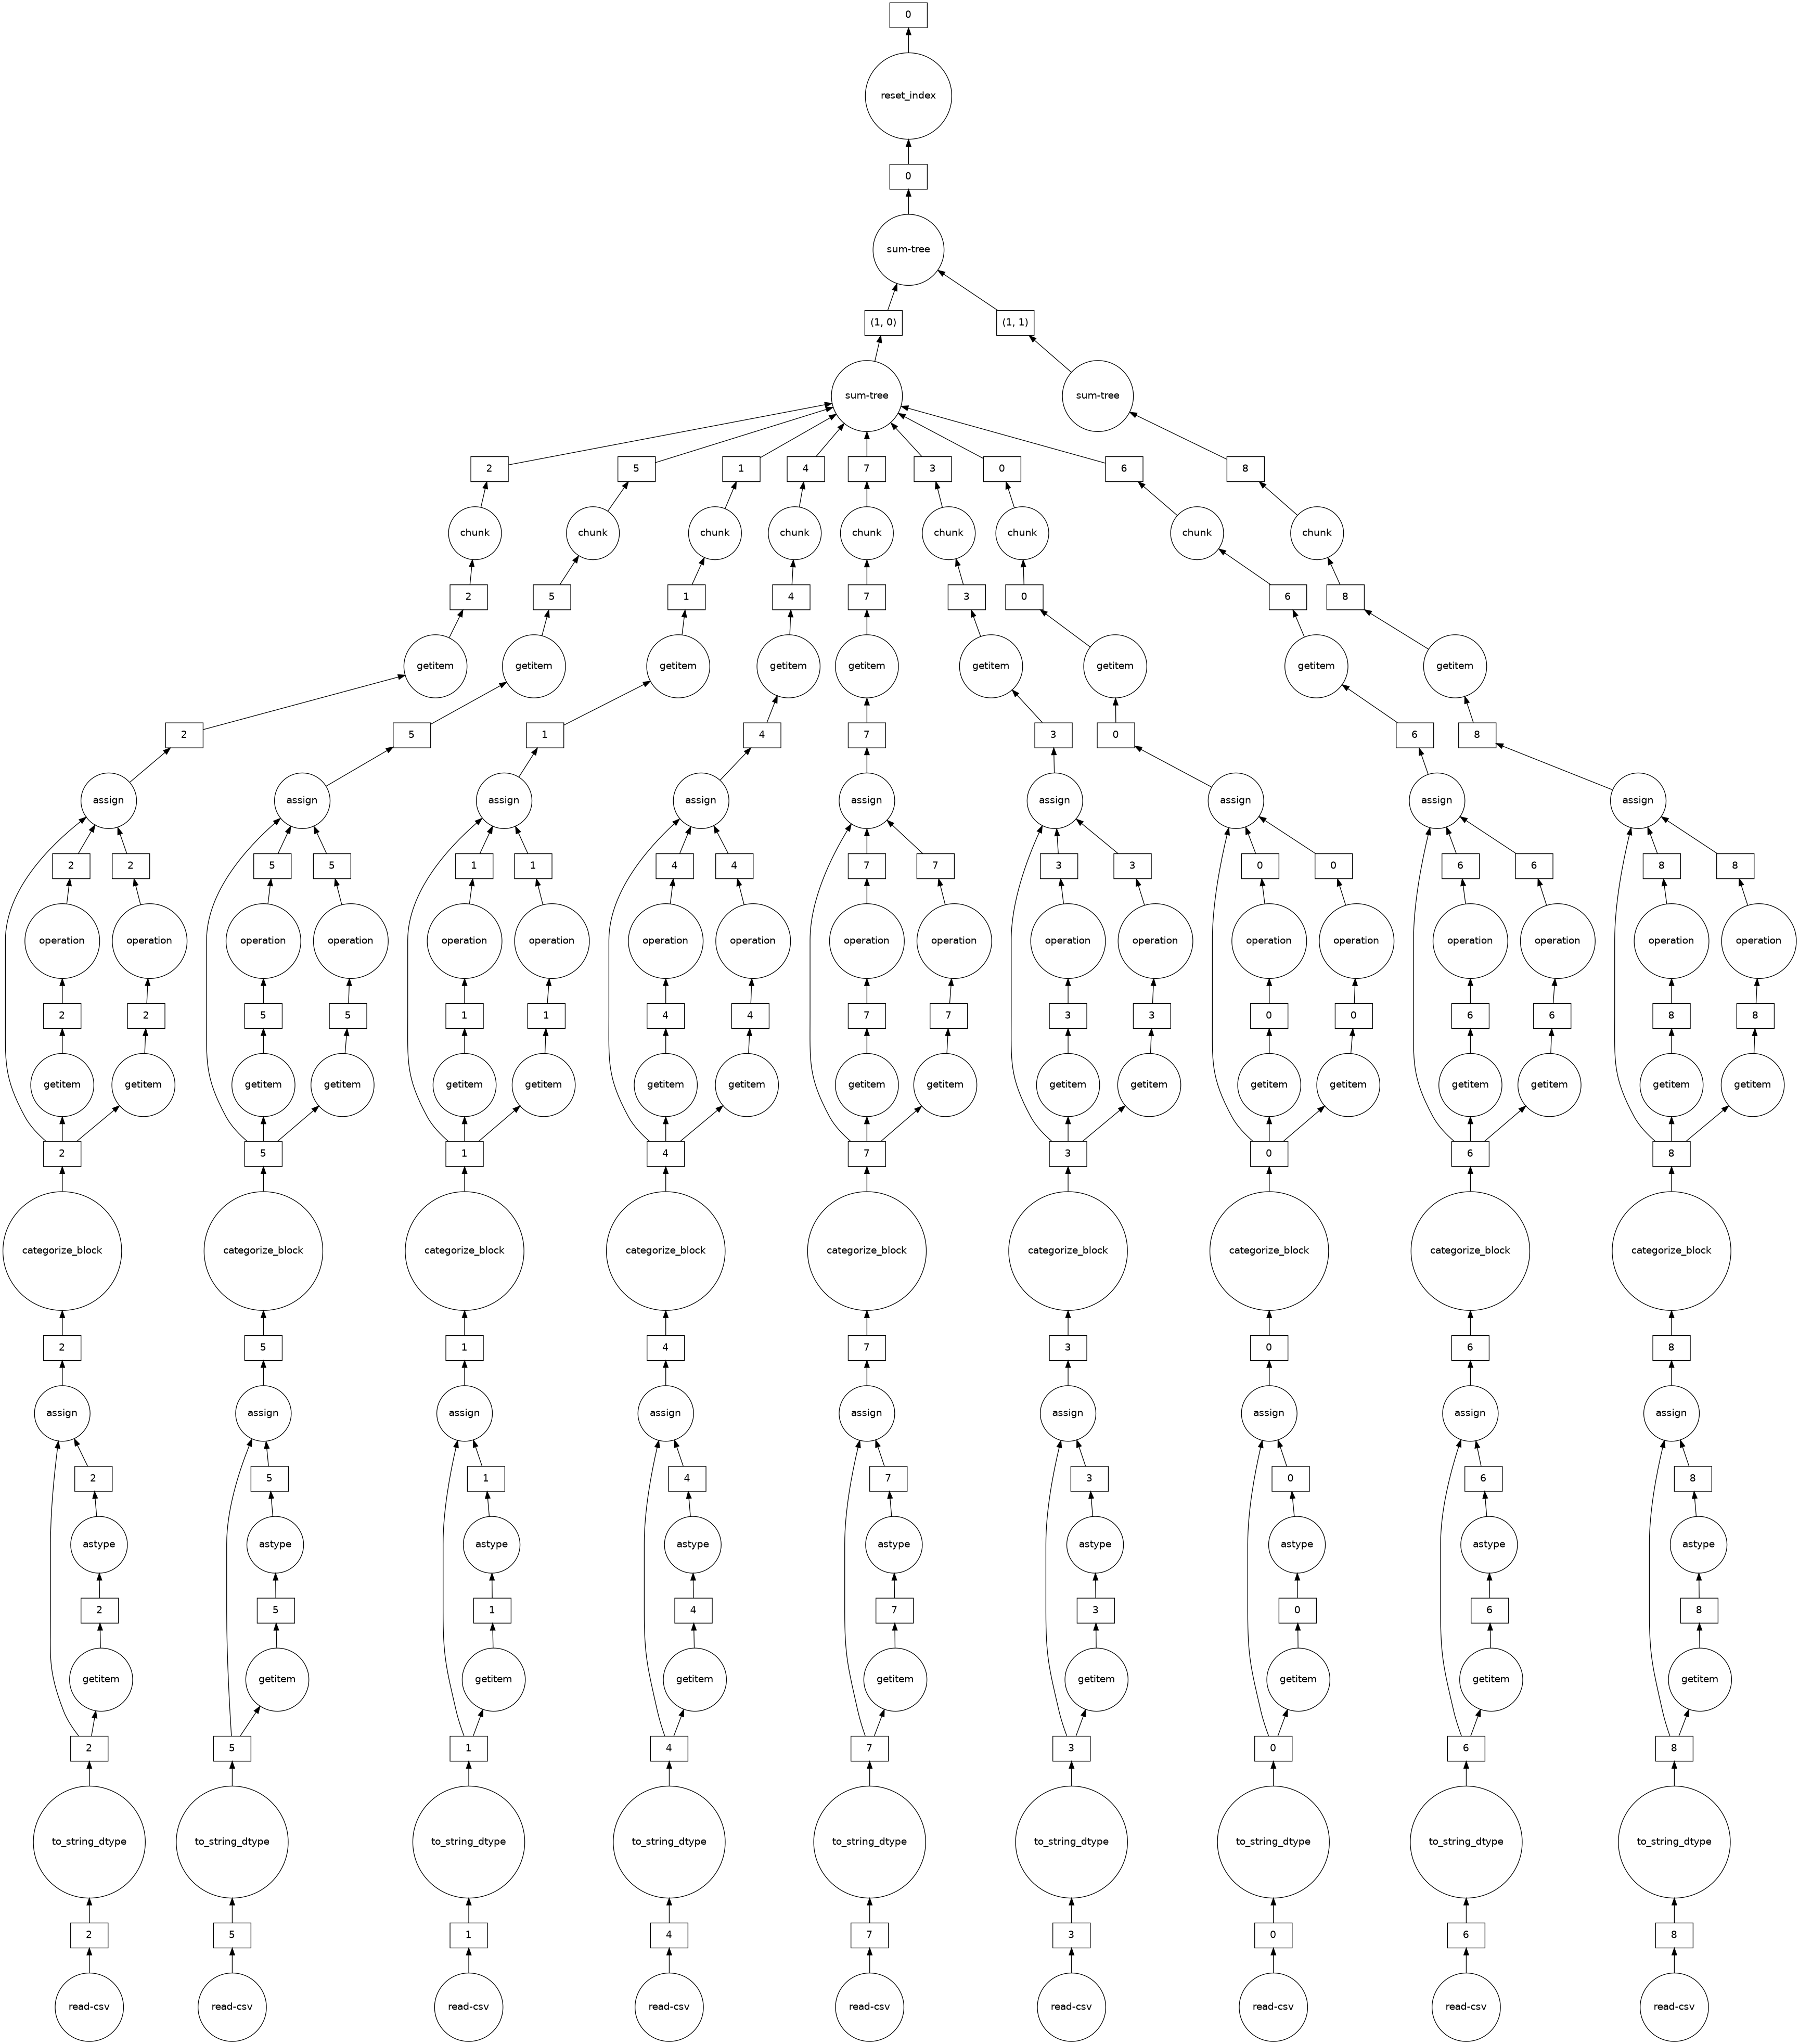

In [24]:
from dask.dot import dot_graph 
interaction_array = df.groupby(['track_idx', 'user_idx'])['playcount'].sum().reset_index()

result= interaction_array.__dask_graph__() 
dot_graph(result)


In [25]:
interaction_array

,track_idx,user_idx,playcount
npartitions=1,,,
,int16,int32,float64
,...,...,...


In [26]:
interaction_array= interaction_array.compute() 
interaction_array

,track_idx,user_idx,playcount
0,0,15780,3.0
1,0,76968,1.0
2,0,134525,2.0
3,0,231541,1.0
4,0,305348,1.0
...,...,...,...
9711296,30458,902360,1.0
9711297,30458,913310,1.0
9711298,30458,922319,1.0
9711299,30458,925779,1.0


In [27]:
## create a sparse matrix 

row_indicies= interaction_array['track_idx']
row_indicies

0              0
1              0
2              0
3              0
4              0
           ...  
9711296    30458
9711297    30458
9711298    30458
9711299    30458
9711300    30458
Name: track_idx, Length: 9711301, dtype: int16

In [33]:
row_indicies

0              0
1              0
2              0
3              0
4              0
           ...  
9711296    30458
9711297    30458
9711298    30458
9711299    30458
9711300    30458
Name: track_idx, Length: 9711301, dtype: int16

In [ ]:
col_indicies= interaction_array['user_idx']


0           15780
1           76968
2          134525
3          231541
4          305348
            ...  
9711296    902360
9711297    913310
9711298    922319
9711299    925779
9711300    943722
Name: user_idx, Length: 9711301, dtype: int32

In [59]:
values= interaction_array['playcount']
values

0          3.0
1          1.0
2          2.0
3          1.0
4          1.0
          ... 
9711296    1.0
9711297    1.0
9711298    1.0
9711299    1.0
9711300    1.0
Name: playcount, Length: 9711301, dtype: float64

In [60]:
n_users

np.int64(962037)

In [61]:
n_tracks = unique_tracks
n_tracks

<dask_expr.expr.Scalar: expr=(DropDuplicates(frame=ArrowStringConversion(frame=FromMapProjectable(6b78f54))['track_id'], split_every=False)).count(), dtype=int64>

In [62]:
n_tracks= n_tracks.compute()
n_tracks

np.int64(30459)

In [63]:
n_tracks

np.int64(30459)

In [64]:
n_tracks

np.int64(30459)

In [65]:
n_users= unique_users
n_users

np.int64(962037)

In [66]:
## build sparse matrix 

sparse_matrix= csr_matrix((values, (row_indicies , col_indicies)), shape=(n_tracks, n_users)) 
sparse_matrix 


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9711301 stored elements and shape (30459, 962037)>

In [67]:
print("sparse matrix shape:", sparse_matrix.shape)
print("non zero elements", sparse_matrix.nnz)

sparse matrix shape: (30459, 962037)
non zero elements 9711301


In [73]:
sparse_matrix.shape[0] * sparse_matrix.shape[1]

29302684983

## Percentage of the values that are not zero 

In [76]:
sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]) * 100 

0.033141335019756815

In [78]:
from sklearn.metrics.pairwise import cosine_similarity

In [79]:
df['track_id']

Dask Series Structure:
npartitions=9
    category[known]
                ...
         ...       
                ...
                ...
Dask Name: getitem, 12 expressions
Expr=(Assign(frame=Categorize(frame=Assign(frame=ArrowStringConversion(frame=FromMapProjectable(6b78f54))), categories={'user_id': 271012    00000b722001882066dff9d2da8a775658053ea0
282179    00001638d6189236866af9bbf309ae6c2347ffdc
413851    0000175652312d12576d9e6b84f600caa24c4715
752325    00001cf0dce3fb22b0df0f3a1d9cd21e38385372
202926    0000267bde1b3a70ea75cf2b2d216cb828e3202b
                            ...                   
819195    ffffdc6c89988cd6119067769162948eacf8b670
844593    ffffe07df4bb5fd929efe42c5728f3a0c1621277
743202    fffff3e690fcda840b716ce7249d8935ff3323fc
571737    fffff67d54a40927c93d03bd6c816b034b59f087
884370    fffff9534445f481b6ab91c345500083d2ce4df1
Name: user_id, Length: 962037, dtype: string, 'track_id': 25631      TRAAAED128E0783FAB
1017033    TRAAAHD128F42635A5
704344     TRAAAQO

In [80]:
np.where(df['track_id'].cat.categories == 'TRZZZCN128F9317A03')

(array([30456]),)

In [84]:
in_dex= 30456

In [86]:
input_array= sparse_matrix[in_dex]
input_array

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15 stored elements and shape (1, 962037)>

In [94]:
similarity_scores= cosine_similarity(input_array, sparse_matrix)

In [103]:
np.sort(similarity_scores)[-8:][::-1]

array([[0.        , 0.        , 0.        , ..., 0.66720064, 0.67666495,
        1.        ]], shape=(1, 30459))

In [104]:
similarity_scores.shape

(1, 30459)

In [106]:
similarity_scores

array([[0., 0., 0., ..., 1., 0., 0.]], shape=(1, 30459))

In [105]:
np.argsort(similarity_scores)

array([[20224, 20238, 20237, ..., 15937, 11879, 30456]], shape=(1, 30459))

In [110]:
similarity_scores

array([[0., 0., 0., ..., 1., 0., 0.]], shape=(1, 30459))

In [111]:
similarity_scores.iloc[20224]

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'